### baseline_05: Introduction of Ridge
- previous models were improving accuracy with each added feature
- MAE improvement stalled when adding cartridge geometry; feature redundancy
- linear models were fine for ensuring the models could learn to predict bullet velocity but are having difficulties with nuance

In [2]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error

import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("308_baseline_data.csv")
df.head(20)

,cartridge,bullet_diameter,bullet_brand,bullet_type,bullet_weight,powder_type,burn_rate_index,charge_weight,velocity_fps,barrel_length,data_source,primer,twist_rate,coal
0,308_win,0.308,lapua,als,57.0,vihtavuori_n110,64,27.5,3481,24.0,vihtavuori,large_rifle_generic,12.0,2.638
1,308_win,0.308,lapua,g589_ot,100.0,vihtavuori_n120,81,33.6,2890,24.0,vihtavuori,large_rifle_generic,12.0,2.638
2,308_win,0.308,lapua,g589_ot,100.0,vihtavuori_n130,84,37.8,2986,24.0,vihtavuori,large_rifle_generic,12.0,2.638
3,308_win,0.308,lapua,g589_ot,100.0,vihtavuori_n133,89,41.7,3097,24.0,vihtavuori,large_rifle_generic,12.0,2.638
4,308_win,0.308,lapua,g589_ot,100.0,vihtavuori_n135,102,43.2,3123,24.0,vihtavuori,large_rifle_generic,12.0,2.638
5,308_win,0.308,lapua,g589_ot,100.0,vihtavuori_n540,117,47.4,3114,24.0,vihtavuori,large_rifle_generic,12.0,2.638
6,308_win,0.308,lapua,hpce_otce,100.0,vihtavuori_n110,64,20.4,2333,24.0,vihtavuori,large_rifle_generic,12.0,2.638
7,308_win,0.308,lapua,hpce_otce,100.0,vihtavuori_n120,81,30.6,2663,24.0,vihtavuori,large_rifle_generic,12.0,2.638
8,308_win,0.308,lapua,hpce_otce,100.0,vihtavuori_n130,84,33.7,2794,24.0,vihtavuori,large_rifle_generic,12.0,2.638
9,308_win,0.308,lapua,hpce_otce,100.0,vihtavuori_n133,89,40.6,3012,24.0,vihtavuori,large_rifle_generic,12.0,2.638


In [6]:
features = ["charge_weight", "bullet_weight", "burn_rate_index", "coal"]
target = "velocity_fps"

X = df[features].astype(float)
y = df[target].astype(float)

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (1001, 4)  Test: (251, 4)


In [24]:
mean_pred = np.full(shape=y_test.shape, fill_value=y_train.mean())
floor_mae = mean_absolute_error(y_test, mean_pred)
print(f"FLOOR MAE (test): {floor_mae:.2f}ft/s")

FLOOR MAE (test): 190.84ft/s


In [25]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

model.fit(X_train, y_train)
preds = model.predict(X_test)

model_mae = mean_absolute_error(y_test, preds)
print(f"MODEL MAE (test): {model_mae:.2f}ft/s")


MODEL MAE (test): 51.18ft/s


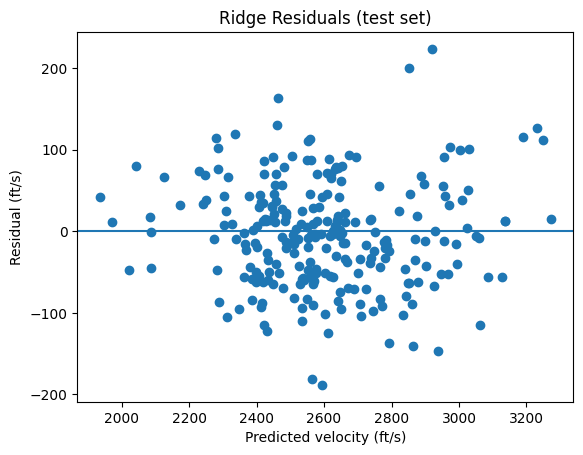

In [26]:
residuals = y_test.to_numpy() - preds

plt.scatter(preds, residuals)
plt.axhline(0)
plt.xlabel("Predicted velocity (ft/s)")
plt.ylabel("Residual (ft/s)")
plt.title("Ridge Residuals (test set)")
plt.show()

### Interpretation of results:
- No apparent shift in prediction accuracy between baseline Ridge and the ordinary regression model:
  - OLS ~ Ridge
  - Same core features
  - Similar MAE
  - Similar residuals
  - Can be interpreted as *core feature set is well-conditioned and not overfitting*
- I am taking this as evidence that the foundations are sound and there is nothing here that Ridge would need to address.